In [1]:
!pip install genomic-benchmarks torch-geometric networkx

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.7 MB/s eta 0:00:00
  Created wheel for genomic-benchmarks: filename=genomic_benchmarks-1.0.0-py3-none-any.whl size=22550 sha256=a1d06c878191febaa38eeaf155bd49247d1c0ab640a806fc168b8b513042df99
  Stored in directory: /root/.cache/pip/wheels/9a/3a/9a/0f21797a390f81beeeb52e9ccc71e6d5e262786ecd01e046bf
Successfully built genomic-benchmarks


# **Dataset Load**

In [2]:
from genomic_benchmarks.dataset_getters.pytorch_datasets import get_dataset

# Dataset 1 (Main)
train_data = get_dataset("human_nontata_promoters", split="train")
test_data  = get_dataset("human_nontata_promoters", split="test")

print(len(train_data), len(test_data))
print("Total samples:", len(train_data) + len(test_data))

/usr/local/lib/python3.12/dist-packages/genomic_benchmarks/utils/datasets.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/usr/local/lib/python3.12/dist-packages/genomic_benchmarks/utils/datasets.py:50: UserWarning: No version specified. Using version 0.
  warnings.warn(f"No version specified. Using version {metadata['version']}.")


27097 9034
Total samples: 36131


# **Convert to DataFrame**

In [3]:
import pandas as pd

def to_df(dataset):
    seqs, labels = [], []
    
    for seq, label in dataset:
        seqs.append(seq)
        labels.append(label)
    
    return pd.DataFrame({
        "sequence": seqs,
        "label": labels
    })

df = to_df(train_data)
df.head()

,sequence,label
0,GGCCACTGCACTCCAGCCGGGTTGACAGAGGGAGACTCCATCCCAA...,0
1,AGGTGCGATCCCTTCTCCTTTGGGGTTTACTTTCTCAGAGAAAAAA...,0
2,AGCCCTCGACCCCCACAGGCAGTGGCTCCAGGCTGTTGGGGAGGAT...,0
3,AAGGTACCTTTGCTTCCAGGGGAAACCAATTCTGCCTACTTGGGAA...,0
4,AGAAACGGGCGGGTTATTGACGAGTTCCCTCCCTCTCGCAGTTTTA...,0


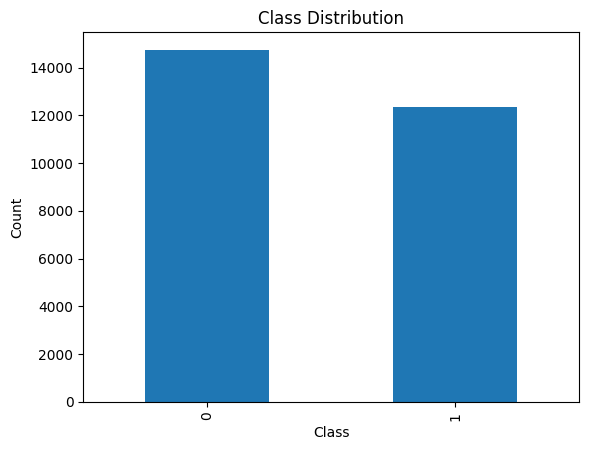

In [4]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

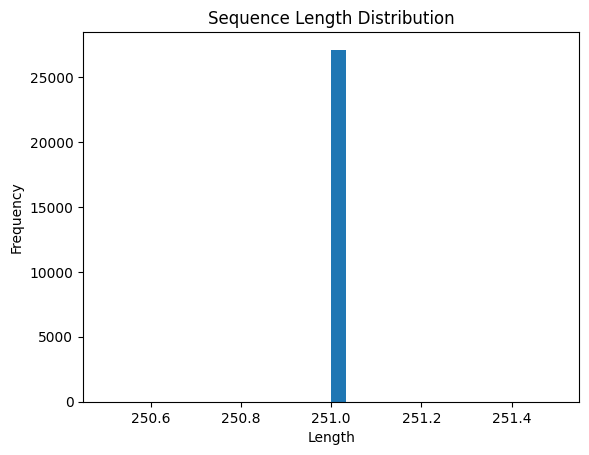

In [5]:
df['seq_len'] = df['sequence'].apply(len)

plt.hist(df['seq_len'], bins=30)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

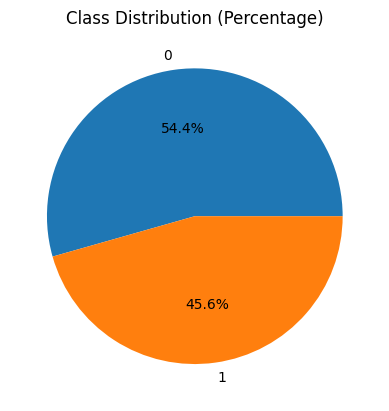

In [6]:
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Class Distribution (Percentage)")
plt.ylabel("")
plt.show()

# **Train / Val Split**

In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print(len(train_df), len(val_df))

21677 5420


In [8]:
test_df = to_df(test_data)

print("Test:", len(test_df))

Test: 9034


# **DNA → k-mer Graph**

In [9]:
import random
import numpy as np
import networkx as nx
import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Thesis setting: k=6 preserves richer biological motifs than k=3.
# You can tune this later using validation accuracy.
K = 6

def build_kmer_graph(sequence, k=K):
    """
    Build a positional k-mer graph from one DNA sequence.

    Important fix:
    - Each k-mer occurrence becomes a separate node.
    - Repeated k-mers are NOT collapsed.
    - Consecutive k-mers are connected in both directions.
    """
    sequence = str(sequence).upper()
    kmers = [sequence[i:i+k] for i in range(max(len(sequence) - k + 1, 0))]

    G = nx.DiGraph()

    # Handle very short sequences safely
    if len(kmers) == 0:
        kmers = [sequence]

    for i, kmer in enumerate(kmers):
        G.add_node(
            i,
            kmer=kmer,
            position=i,
            seq_len=len(kmers)
        )

    for i in range(len(kmers) - 1):
        # Add both directions so GCN can pass messages left-to-right and right-to-left
        G.add_edge(i, i + 1)
        G.add_edge(i + 1, i)

    return G


# **Node Feature**

In [10]:
def kmer_to_vector(kmer, position=0, seq_len=1, k=K):
    """
    Convert a k-mer occurrence into a numeric feature vector.

    Features:
    1. One-hot nucleotide encoding: A,T,G,C -> 4*k values
    2. Normalized position in sequence -> 1 value
    3. GC content of k-mer -> 1 value
    4. Unknown/N fraction -> 1 value
    """
    mapping = {'A': 0, 'T': 1, 'G': 2, 'C': 3}

    # Pad/truncate so every node has fixed feature dimension
    kmer = str(kmer).upper()
    if len(kmer) < k:
        kmer = kmer + ("N" * (k - len(kmer)))
    else:
        kmer = kmer[:k]

    vec = []
    unknown_count = 0

    for c in kmer:
        one_hot = [0.0, 0.0, 0.0, 0.0]
        if c in mapping:
            one_hot[mapping[c]] = 1.0
        else:
            unknown_count += 1
        vec.extend(one_hot)

    denom = max(seq_len - 1, 1)
    normalized_position = position / denom

    gc_count = kmer.count("G") + kmer.count("C")
    gc_content = gc_count / k

    unknown_fraction = unknown_count / k

    vec.extend([normalized_position, gc_content, unknown_fraction])
    return vec

IN_DIM = 4 * K + 3
print("K:", K)
print("Node feature dimension:", IN_DIM)


K: 6
Node feature dimension: 27


# **Graph → PyTorch Format**

In [11]:
from torch_geometric.data import Data

def graph_to_pyg(G):
    """
    Convert NetworkX graph to PyTorch Geometric Data.
    """
    x_list = []

    for node_id in G.nodes():
        attr = G.nodes[node_id]
        x_list.append(
            kmer_to_vector(
                attr["kmer"],
                position=attr["position"],
                seq_len=attr["seq_len"],
                k=K
            )
        )

    x = torch.tensor(x_list, dtype=torch.float)

    edges = list(G.edges())
    if len(edges) == 0:
        # Single-node graph fallback
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    data = Data(x=x, edge_index=edge_index)
    return data


# **Dataset → Graph Dataset**

In [12]:
def create_graph_dataset(df, k=K):
    dataset = []

    for _, row in df.iterrows():
        seq = row["sequence"]
        label = int(row["label"])

        G = build_kmer_graph(seq, k=k)
        data = graph_to_pyg(G)

        # CrossEntropyLoss expects class index, not one-hot label
        data.y = torch.tensor([label], dtype=torch.long)

        dataset.append(data)

    return dataset


In [13]:
train_graphs = create_graph_dataset(train_df, k=K)
val_graphs = create_graph_dataset(val_df, k=K)
test_graphs = create_graph_dataset(test_df, k=K)

print("Train graphs:", len(train_graphs))
print("Val graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))
print("Example graph:", train_graphs[0])
print("Example x shape:", train_graphs[0].x.shape)

Train graphs: 21677
Val graphs: 5420
Test graphs: 9034
Example graph: Data(x=[246, 27], edge_index=[2, 490], y=[1])
Example x shape: torch.Size([246, 27])


In [14]:

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

def pyg_to_networkx_for_plot(data, max_nodes=30):
    """
    Convert one PyTorch Geometric graph back to NetworkX for visualization.
    Only the first max_nodes are shown to keep the figure readable.
    """
    G_plot = nx.Graph()
    num_nodes = min(data.num_nodes, max_nodes)

    for i in range(num_nodes):
        G_plot.add_node(i)

    edge_index = data.edge_index.cpu().numpy()
    for src, dst in edge_index.T:
        if src < num_nodes and dst < num_nodes:
            G_plot.add_edge(int(src), int(dst))

    return G_plot


def show_kmer_transition_table(sequence, k=K, max_kmers=15):
    """
    Show DNA sequence as overlapping k-mers.
    This table is useful before showing the graph.
    """
    sequence = str(sequence).upper()
    kmers = [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

    rows = []
    for i, kmer in enumerate(kmers[:max_kmers]):
        rows.append([i, i + k - 1, kmer])

    table_df = pd.DataFrame(rows, columns=["Start Position", "End Position", "k-mer"])

    fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(table_df))))
    ax.axis("off")
    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center",
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.3)
    ax.set_title("DNA Sequence Converted into Overlapping k-mers", fontsize=13, pad=12)
    plt.show()

    return table_df


def visualize_kmer_graph(data, sequence=None, k=K, max_nodes=30):
    """
    Visualize one constructed DNA graph.
    Node labels show k-mer position.
    For readability, only the first max_nodes nodes are displayed.
    """
    G_plot = pyg_to_networkx_for_plot(data, max_nodes=max_nodes)

    # Linear layout because k-mer transitions follow sequence order
    pos = {node: (node, 0) for node in G_plot.nodes()}

    plt.figure(figsize=(14, 3.5))
    nx.draw(
        G_plot,
        pos,
        with_labels=True,
        node_size=900,
        font_size=9,
        width=1.8
    )

    labels = {i: f"k{i}" for i in G_plot.nodes()}
    nx.draw_networkx_labels(G_plot, pos, labels=labels, font_size=9)

    title = "Constructed DNA k-mer Graph"
    if sequence is not None:
        title += f"  |  Nodes shown: first {min(data.num_nodes, max_nodes)} of {data.num_nodes}"

    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.show()


def visualize_feature_matrix(data, max_nodes=25):
    """
    Visualize node feature matrix.
    Rows = nodes/k-mers, columns = encoded biological/positional features.
    """
    x = data.x[:max_nodes].detach().cpu().numpy()

    plt.figure(figsize=(12, 5))
    plt.imshow(x, aspect="auto")
    plt.colorbar(label="Feature value")
    plt.xlabel("Feature index")
    plt.ylabel("Graph node / k-mer position")
    plt.title("Node Feature Matrix After Graph Construction")
    plt.show()


def visualize_graph_statistics(data):
    """
    Show simple graph statistics useful for thesis explanation.
    """
    G_plot = pyg_to_networkx_for_plot(data, max_nodes=data.num_nodes)
    degrees = [deg for _, deg in G_plot.degree()]

    print("Graph Statistics")
    print("----------------")
    print("Number of nodes:", data.num_nodes)
    print("Number of directed edges in PyG:", data.edge_index.shape[1])
    print("Number of undirected edges for visualization:", G_plot.number_of_edges())
    print("Average node degree:", round(np.mean(degrees), 3))

    plt.figure(figsize=(7, 4))
    plt.bar(range(len(degrees)), degrees)
    plt.xlabel("Node index")
    plt.ylabel("Degree")
    plt.title("Degree of Each k-mer Node")
    plt.show()


Example DNA sequence length: 251
Example label: 1


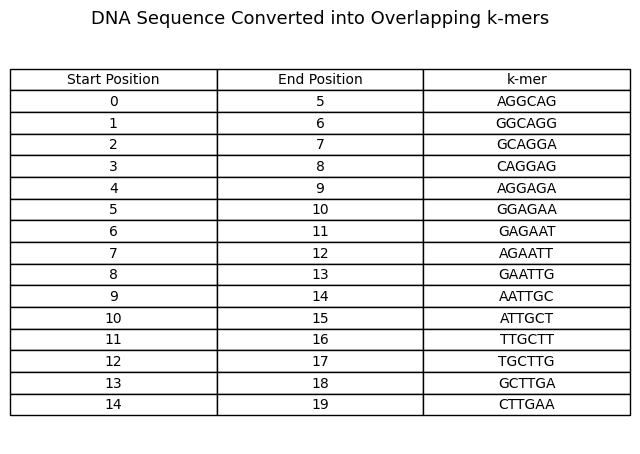

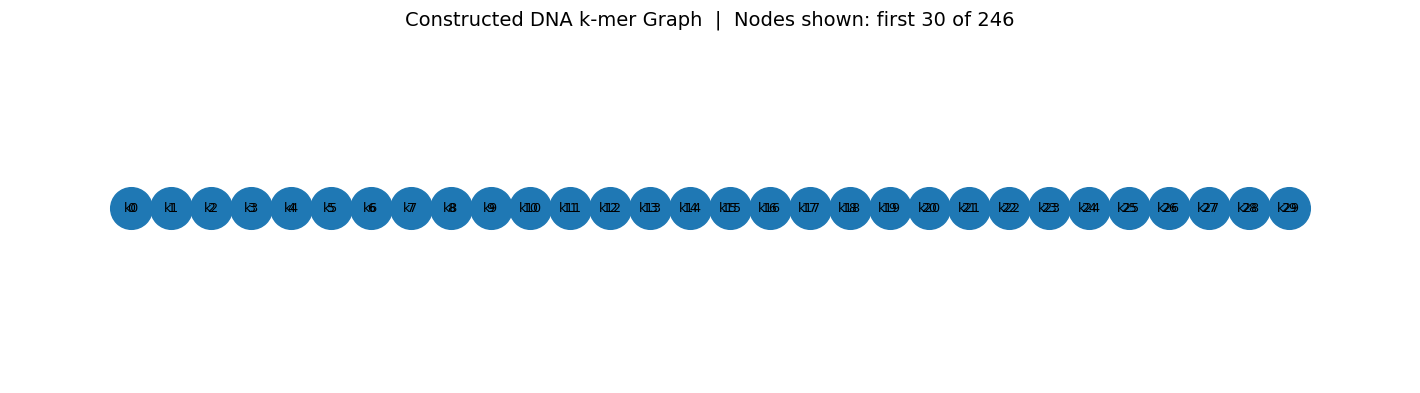

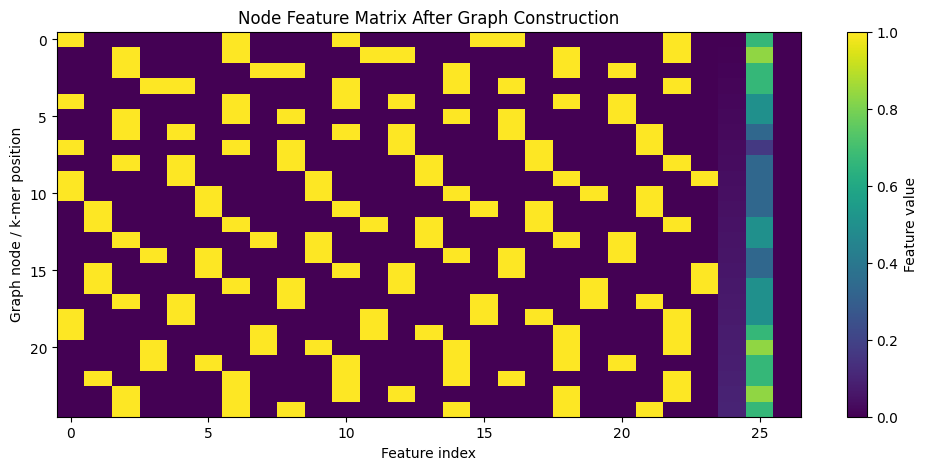

Graph Statistics
----------------
Number of nodes: 246
Number of directed edges in PyG: 490
Number of undirected edges for visualization: 245
Average node degree: 1.992


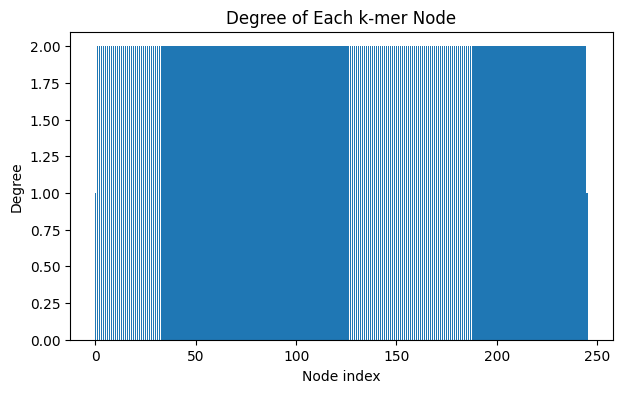

In [15]:

# Pick one example sequence and its constructed graph
example_index = 0
example_sequence = train_df.iloc[example_index]["sequence"]
example_graph = train_graphs[example_index]

print("Example DNA sequence length:", len(example_sequence))
print("Example label:", train_df.iloc[example_index]["label"])

# Figure 1: DNA sequence to k-mer table
kmer_table = show_kmer_transition_table(example_sequence, k=K, max_kmers=15)

# Figure 2: k-mer transition graph
visualize_kmer_graph(example_graph, sequence=example_sequence, k=K, max_nodes=30)

# Figure 3: node feature matrix
visualize_feature_matrix(example_graph, max_nodes=25)

# Figure 4: simple graph statistics
visualize_graph_statistics(example_graph)

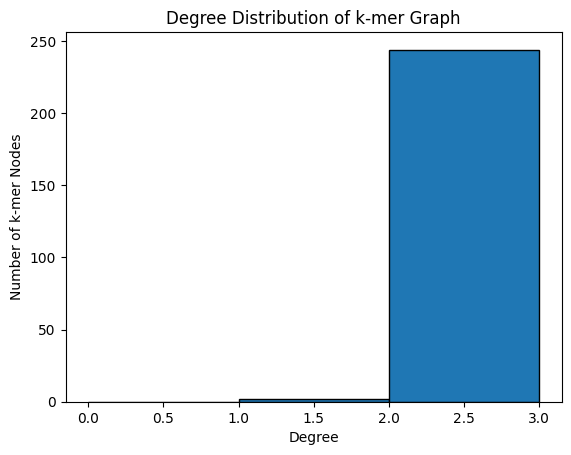

In [16]:
from torch_geometric.utils import degree
import matplotlib.pyplot as plt

degrees = degree(
    example_graph.edge_index[0],
    num_nodes=example_graph.num_nodes
).cpu().numpy()

plt.hist(degrees, bins=range(0, int(max(degrees)) + 2), edgecolor="black")
plt.title("Degree Distribution of k-mer Graph")
plt.xlabel("Degree")
plt.ylabel("Number of k-mer Nodes")
plt.show()

In [17]:
print(dir())

['Data', 'IN_DIM', 'In', 'K', 'Out', 'SEED', '_', '_3', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_exit_code', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'build_kmer_graph', 'create_graph_dataset', 'degree', 'degrees', 'df', 'example_graph', 'example_index', 'example_sequence', 'exit', 'get_dataset', 'get_ipython', 'graph_to_pyg', 'kmer_table', 'kmer_to_vector', 'np', 'nx', 'pd', 'plt', 'pyg_to_networkx_for_plot', 'quit', 'random', 'show_kmer_transition_table', 'test_data', 'test_df', 'test_graphs', 'to_df', 'torch', 'train_data', 'train_df', 'train_graphs', 'train_test_split', 'val_df', 'val_graphs', 'visualize_feature_matrix', 'visualize_graph_statistics', 'visualize_kmer_graph']


# **DataLoader**

In [18]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)

In [19]:
import torch

torch.save({
    "train_loader": train_loader,
    "val_loader": val_loader,
    "test_loader": test_loader,
    "IN_DIM": IN_DIM
}, "human_nontata_graph_loaders.pt")

print("Saved loaders successfully.")

Saved loaders successfully.


In [20]:
%%writefile utils.py

import torch
import torch.nn.functional as F

# -----------------------------
# drop_edges
# -----------------------------
def drop_edges(data, p=0.2):
    data = data.clone()
    edge_index = data.edge_index

    num_edges = edge_index.size(1)
    if num_edges <= 1:
        return data

    mask = torch.rand(num_edges, device=edge_index.device) > p

    if mask.sum() == 0:
        keep_idx = torch.randint(0, num_edges, (1,), device=edge_index.device)
        mask[keep_idx] = True

    data.edge_index = edge_index[:, mask]
    return data


# -----------------------------
# mask_nodes
# -----------------------------
def mask_nodes(data, p=0.2):
    data = data.clone()
    x = data.x.clone()

    mask = torch.rand(x.size(0), device=x.device) > p
    x[~mask] = 0.0

    data.x = x
    return data


# -----------------------------
# contrastive_loss
# -----------------------------
def contrastive_loss(z1, z2, temp=0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits_12 = torch.mm(z1, z2.t()) / temp
    logits_21 = torch.mm(z2, z1.t()) / temp

    labels = torch.arange(z1.size(0), device=z1.device)

    loss_12 = F.cross_entropy(logits_12, labels)
    loss_21 = F.cross_entropy(logits_21, labels)

    return (loss_12 + loss_21) / 2


# -----------------------------
# train_supervised
# -----------------------------
def train_supervised(loader, model, optimizer, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for data in loader:
        data = data.to(device)

        out = model(data.x, data.edge_index, data.batch)
        loss = F.cross_entropy(out, data.y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = data.y.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (out.argmax(dim=1) == data.y).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


# -----------------------------
# evaluate
# -----------------------------
def evaluate(loader, model, device):
    model.eval()

    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data.x, data.edge_index, data.batch)
            loss = F.cross_entropy(out, data.y)

            preds = out.argmax(dim=1)

            batch_size = data.y.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == data.y).sum().item()
            total_samples += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())

    return total_loss / total_samples, total_correct / total_samples, all_preds, all_labels

Writing utils.py


In [21]:
import torch

def drop_edges(data, p=0.2):
    """
    Randomly remove edges for GraphCL augmentation.
    Keeps at least one edge when possible.
    """
    data = data.clone()
    edge_index = data.edge_index

    num_edges = edge_index.size(1)
    if num_edges <= 1:
        return data

    mask = torch.rand(num_edges, device=edge_index.device) > p

    # Avoid removing every edge
    if mask.sum() == 0:
        keep_idx = torch.randint(0, num_edges, (1,), device=edge_index.device)
        mask[keep_idx] = True

    data.edge_index = edge_index[:, mask]
    return data

In [22]:
def mask_nodes(data, p=0.2):
    """
    Randomly mask node features for GraphCL augmentation.
    Keeps graph structure unchanged.
    """
    data = data.clone()
    x = data.x.clone()

    mask = torch.rand(x.size(0), device=x.device) > p
    x[~mask] = 0.0

    data.x = x
    return data

# **GCN Encoder (Backbone)**

In [23]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # graph-level embedding
        x = global_mean_pool(x, batch)
        return x


# **GraphCL Contrastive Loss**

In [24]:
import torch.nn.functional as F

def contrastive_loss(z1, z2, temp=0.5):
    """
    Symmetric GraphCL contrastive loss.
    Each graph view should be closest to its augmented pair.
    """
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits_12 = torch.mm(z1, z2.t()) / temp
    logits_21 = torch.mm(z2, z1.t()) / temp

    labels = torch.arange(z1.size(0), device=z1.device)

    loss_12 = F.cross_entropy(logits_12, labels)
    loss_21 = F.cross_entropy(logits_21, labels)

    return (loss_12 + loss_21) / 2


# **Taining Loop (GraphCL Pretraining)**

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCNEncoder(in_dim=IN_DIM, hidden_dim=128, dropout=0.1).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0002,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4
)

graphcl_history = {"epoch": [], "loss": []}

print("Using device:", device)

Using device: cuda


In [26]:
def train_graphcl(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        g1 = drop_edges(data, p=0.15)
        g2 = mask_nodes(data, p=0.15)

        z1 = model(g1.x, g1.edge_index, g1.batch)
        z2 = model(g2.x, g2.edge_index, g2.batch)

        loss = contrastive_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [27]:
for epoch in range(1, 101):
    loss = train_graphcl(train_loader)

    scheduler.step(loss)

    graphcl_history["epoch"].append(epoch)
    graphcl_history["loss"].append(loss)

    print(f"GraphCL Epoch {epoch:02d}, Loss: {loss:.4f}")


GraphCL Epoch 01, Loss: 2.5341
GraphCL Epoch 02, Loss: 2.2545
GraphCL Epoch 03, Loss: 2.2033
GraphCL Epoch 04, Loss: 2.1677
GraphCL Epoch 05, Loss: 2.1429
GraphCL Epoch 06, Loss: 2.1252
GraphCL Epoch 07, Loss: 2.1128
GraphCL Epoch 08, Loss: 2.0992
GraphCL Epoch 09, Loss: 2.0923
GraphCL Epoch 10, Loss: 2.0856
GraphCL Epoch 11, Loss: 2.0762
GraphCL Epoch 12, Loss: 2.0696
GraphCL Epoch 13, Loss: 2.0650
GraphCL Epoch 14, Loss: 2.0628
GraphCL Epoch 15, Loss: 2.0554
GraphCL Epoch 16, Loss: 2.0520
GraphCL Epoch 17, Loss: 2.0512
GraphCL Epoch 18, Loss: 2.0427
GraphCL Epoch 19, Loss: 2.0453
GraphCL Epoch 20, Loss: 2.0412
GraphCL Epoch 21, Loss: 2.0361
GraphCL Epoch 22, Loss: 2.0352
GraphCL Epoch 23, Loss: 2.0317
GraphCL Epoch 24, Loss: 2.0287
GraphCL Epoch 25, Loss: 2.0272
GraphCL Epoch 26, Loss: 2.0309
GraphCL Epoch 27, Loss: 2.0228
GraphCL Epoch 28, Loss: 2.0218
GraphCL Epoch 29, Loss: 2.0182
GraphCL Epoch 30, Loss: 2.0170
GraphCL Epoch 31, Loss: 2.0175
GraphCL Epoch 32, Loss: 2.0189
GraphCL 

In [28]:
torch.save(model.state_dict(), "gcn_graphcl_encoder.pt")
print("GraphCL encoder saved.")

GraphCL encoder saved.


# **Classification Model (Encoder + Head)**

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GraphClassifier(nn.Module):
    def __init__(self, encoder, hidden_dim, num_classes=2, dropout=0.3):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        graph_embedding = self.encoder(x, edge_index, batch)
        graph_embedding = self.dropout(graph_embedding)
        logits = self.fc(graph_embedding)
        return logits

In [30]:
def batch_accuracy(logits, y):
    preds = logits.argmax(dim=1)
    correct = (preds == y).sum().item()
    return correct / y.size(0)

# **Supervised Training Loop**

In [31]:
def train_supervised(loader, model, optimizer, device):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for data in loader:
        data = data.to(device)

        out = model(data.x, data.edge_index, data.batch)
        loss = F.cross_entropy(out, data.y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = data.y.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (out.argmax(dim=1) == data.y).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


# **Evaluation**

In [32]:
def evaluate(loader, model, device):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data.x, data.edge_index, data.batch)
            loss = F.cross_entropy(out, data.y)
            preds = out.argmax(dim=1)

            batch_size = data.y.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == data.y).sum().item()
            total_samples += batch_size

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(data.y.cpu().numpy().tolist())

    return total_loss / total_samples, total_correct / total_samples, all_preds, all_labels

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = model
model_cls = GraphClassifier(encoder, hidden_dim=128, num_classes=2, dropout=0.2).to(device)

optimizer_cls = torch.optim.AdamW(
    model_cls.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls,
    mode="max",
    factor=0.5,
    patience=5
)

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0
best_state = None

for epoch in range(1, 101):
    train_loss, train_acc = train_supervised(train_loader, model_cls, optimizer_cls, device)
    val_loss, val_acc, _, _ = evaluate(val_loader, model_cls, device)

    scheduler.step(val_acc)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model_cls.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

if best_state is not None:
    model_cls.load_state_dict(best_state)

print("Best Validation Accuracy:", best_val_acc)

Epoch 01 | Train Loss: 0.5754 | Train Acc: 0.6926 | Val Loss: 0.5053 | Val Acc: 0.7644
Epoch 02 | Train Loss: 0.5105 | Train Acc: 0.7502 | Val Loss: 0.4879 | Val Acc: 0.7727
Epoch 03 | Train Loss: 0.4943 | Train Acc: 0.7604 | Val Loss: 0.4754 | Val Acc: 0.7779
Epoch 04 | Train Loss: 0.4837 | Train Acc: 0.7665 | Val Loss: 0.4645 | Val Acc: 0.7862
Epoch 05 | Train Loss: 0.4803 | Train Acc: 0.7673 | Val Loss: 0.4602 | Val Acc: 0.7887
Epoch 06 | Train Loss: 0.4717 | Train Acc: 0.7751 | Val Loss: 0.4531 | Val Acc: 0.7902
Epoch 07 | Train Loss: 0.4692 | Train Acc: 0.7766 | Val Loss: 0.4526 | Val Acc: 0.7915
Epoch 08 | Train Loss: 0.4652 | Train Acc: 0.7786 | Val Loss: 0.4467 | Val Acc: 0.7939
Epoch 09 | Train Loss: 0.4641 | Train Acc: 0.7788 | Val Loss: 0.4424 | Val Acc: 0.7941
Epoch 10 | Train Loss: 0.4577 | Train Acc: 0.7840 | Val Loss: 0.4378 | Val Acc: 0.7970
Epoch 11 | Train Loss: 0.4557 | Train Acc: 0.7841 | Val Loss: 0.4386 | Val Acc: 0.7970
Epoch 12 | Train Loss: 0.4559 | Train Acc: 

In [34]:
torch.save(model_cls.state_dict(), "gcn_classifier.pt")
print("Classifier model saved.")

Classifier model saved.


In [35]:
print(history.keys())
print(len(history["epoch"]))

dict_keys(['epoch', 'train_loss', 'val_loss', 'train_acc', 'val_acc'])
100


In [36]:
test_loss, test_acc, test_preds, test_labels = evaluate(test_loader, model_cls, device)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.3841378021641381
Test Accuracy: 0.8277617887978747


              precision    recall  f1-score   support

           0       0.89      0.78      0.83      4915
           1       0.77      0.89      0.82      4119

    accuracy                           0.83      9034
   macro avg       0.83      0.83      0.83      9034
weighted avg       0.84      0.83      0.83      9034



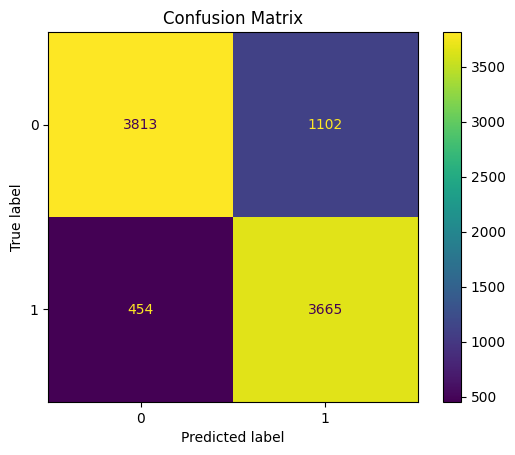

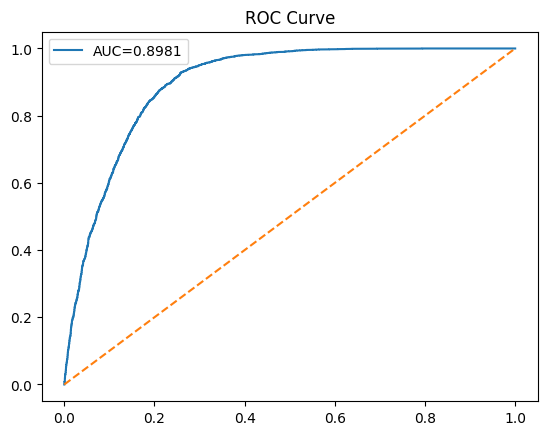

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# classification report
print(classification_report(test_labels, test_preds))

# confusion matrix
cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

# ROC
model_cls.eval()
probs = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model_cls(data.x, data.edge_index, data.batch)
        prob = F.softmax(out, dim=1)[:, 1]
        probs.extend(prob.cpu().numpy())

fpr, tpr, _ = roc_curve(test_labels, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()


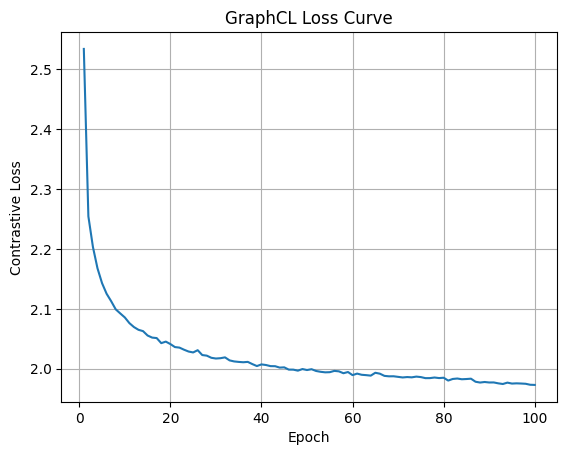

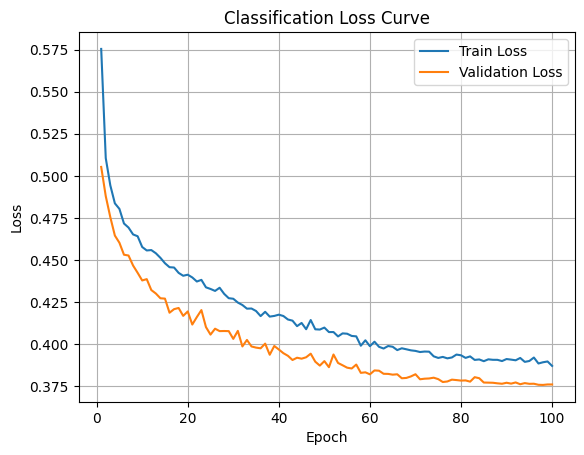

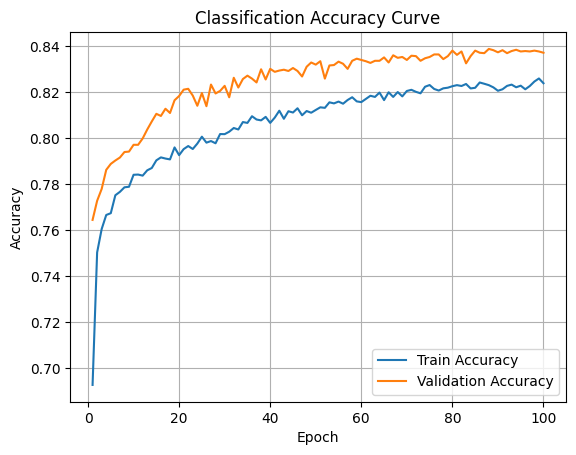

In [38]:
import matplotlib.pyplot as plt

# GraphCL loss
plt.plot(graphcl_history["epoch"], graphcl_history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("GraphCL Loss Curve")
plt.grid(True)
plt.show()

# Classification loss
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# Classification accuracy
plt.plot(history["epoch"], history["train_acc"], label="Train Accuracy")
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# fresh model (no GraphCL)
model_no_pretrain = GraphClassifier(
    GCNEncoder(in_dim=IN_DIM, hidden_dim=128, dropout=0.2),
    hidden_dim=128,
    num_classes=2,
    dropout=0.2
).to(device)

optimizer_no_pretrain = torch.optim.AdamW(
    model_no_pretrain.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

In [40]:
for epoch in range(1, 31):
    train_loss, train_acc = train_supervised(train_loader, model_no_pretrain, optimizer_no_pretrain, device)
    val_loss, val_acc, _, _ = evaluate(val_loader, model_no_pretrain, device)

    print(f"Epoch {epoch} | Val Acc: {val_acc:.4f}")

Epoch 1 | Val Acc: 0.7697
Epoch 2 | Val Acc: 0.7852
Epoch 3 | Val Acc: 0.7994
Epoch 4 | Val Acc: 0.8020
Epoch 5 | Val Acc: 0.8120
Epoch 6 | Val Acc: 0.8199
Epoch 7 | Val Acc: 0.8190
Epoch 8 | Val Acc: 0.8138
Epoch 9 | Val Acc: 0.8197
Epoch 10 | Val Acc: 0.8251
Epoch 11 | Val Acc: 0.8271
Epoch 12 | Val Acc: 0.8288
Epoch 13 | Val Acc: 0.8271
Epoch 14 | Val Acc: 0.8303
Epoch 15 | Val Acc: 0.8087
Epoch 16 | Val Acc: 0.8256
Epoch 17 | Val Acc: 0.8199
Epoch 18 | Val Acc: 0.8284
Epoch 19 | Val Acc: 0.8306
Epoch 20 | Val Acc: 0.8332
Epoch 21 | Val Acc: 0.8330
Epoch 22 | Val Acc: 0.8282
Epoch 23 | Val Acc: 0.8351
Epoch 24 | Val Acc: 0.8253
Epoch 25 | Val Acc: 0.8356
Epoch 26 | Val Acc: 0.8356
Epoch 27 | Val Acc: 0.8356
Epoch 28 | Val Acc: 0.8356
Epoch 29 | Val Acc: 0.8306
Epoch 30 | Val Acc: 0.8341


In [41]:
_, acc_no_pretrain, _, _ = evaluate(test_loader, model_no_pretrain, device)

print("Accuracy WITHOUT GraphCL:", acc_no_pretrain)

Accuracy WITHOUT GraphCL: 0.8257693159176445
